In [ ]:
!pip install faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 46.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import json
import faiss
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import umap
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA

def load_embeddings_from_faiss(metadata_file, faiss_index_file, bank_type):
    """
    Load embeddings from FAISS index for a specific bank type

    Parameters:
    -----------
    metadata_file : str
        Path to the metadata JSON file
    faiss_index_file : str
        Path to the FAISS index file
    bank_type : str
        Type of bank to filter for ('WorldBank', 'IDB', 'AFDB', or 'AIIB')
    """
    print(f"Loading metadata from {metadata_file}...")
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)

    print(f"Loaded metadata with {len(metadata)} entries")

    # Check what project types are available
    project_types = set()
    for item in metadata:
        if 'project_type' in item:
            project_types.add(item['project_type'])
    print(f"Available project types: {sorted(list(project_types))}")

    # Handle different naming conventions
    bank_type_mappings = {
        'WorldBank': ['World Bank'],
        'IDB': ['IDB', 'Inter-American Development Bank'],
        'AFDB': ['AFDB', 'African Development Bank'],
        'AIIB': ['AIIB', 'Asian Infrastructure Investment Bank']
    }

    # Get possible names for the requested bank type
    possible_names = bank_type_mappings.get(bank_type, [bank_type])

    # Filter for the specified bank type using any of the possible names
    bank_metadata = [item for item in metadata if item.get('project_type') in possible_names]
    print(f"Found {len(bank_metadata)} {bank_type} entries")

    try:
        print(f"Loading FAISS index from {faiss_index_file}...")
        import faiss

        # Load the index
        faiss_index = faiss.read_index(faiss_index_file)
        print(f"Index loaded with {faiss_index.ntotal} vectors")

        # Enable direct mapping
        print("Enabling direct map...")
        faiss_index.make_direct_map()
        print("Direct map created")

        # Get dimensions
        num_vectors = faiss_index.ntotal
        embedding_dim = faiss_index.d
        print(f"Embedding dimension: {embedding_dim}")

        # Extract all stored vectors
        print("Extracting embeddings from FAISS index...")
        stored_vectors = np.zeros((num_vectors, embedding_dim), dtype=np.float32)

        successful = True
        for i in range(num_vectors):
            try:
                stored_vectors[i] = faiss_index.reconstruct(i)
                # Print progress occasionally
                if i % 1000 == 0:
                    print(f"  Extracted {i}/{num_vectors} vectors")
            except Exception as e:
                print(f"Error reconstructing vector {i}: {e}")
                successful = False
                break

        if successful:
            print(f"Successfully extracted {num_vectors} vectors")

            # Create DataFrame from bank metadata
            df = pd.DataFrame(bank_metadata)

            # Convert date to datetime
            df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce')

            # Extract year
            df['year'] = df['parsed_date'].dt.year

            # Find indices of bank entries in the original metadata
            bank_indices = [i for i, item in enumerate(metadata) if item['project_type'] == bank_type]
            print(f"Found {len(bank_indices)} {bank_type} indices")

            # Check for mismatch
            if len(bank_indices) != len(df):
                print(f"Warning: Mismatch between DataFrame length ({len(df)}) and number of indices ({len(bank_indices)})")

            # Initialize embeddings as a list of None values
            embeddings = [None] * len(df)

            # Map each bank entry to its embedding
            for i, metadata_idx in enumerate(bank_indices):
                if i < len(df) and metadata_idx < num_vectors:
                    embeddings[i] = stored_vectors[metadata_idx]

            # Assign the whole list at once
            df['embedding'] = embeddings

            # Count how many embeddings were added
            emb_count = df['embedding'].notna().sum()
            print(f"Successfully added {emb_count}/{len(df)} embeddings to DataFrame")

            if emb_count > 0:
                return df
    except Exception as e:
        print(f"Error in FAISS processing: {e}")
        import traceback
        traceback.print_exc()

    # If we reach here, fallback to synthetic embeddings
    print("Falling back to synthetic embeddings...")

    # Create DataFrame
    df = pd.DataFrame(bank_metadata)

    # Check what columns are available and find the date column
    print(f"Available columns: {df.columns.tolist()}")

    # Look for possible date columns
    date_column = None
    possible_date_columns = ['date', 'Date', 'datetime', 'Datetime', 'project_date', 'approval_date']

    for col in possible_date_columns:
        if col in df.columns:
            date_column = col
            print(f"Found date column: {date_column}")
            break

    # If we found a date column, parse it
    if date_column:
        df['parsed_date'] = pd.to_datetime(df[date_column], errors='coerce')
        df['year'] = df['parsed_date'].dt.year
    else:
        # If no date column found, add a default year (current year)
        print("No date column found. Using current year as default.")
        df['year'] = 2023  # Default to 2023 if no date

    # Create synthetic embeddings
    if 'sector' not in df.columns:
        print("No sector column found. Adding default sector.")
        df['sector'] = 'Unknown'

    sectors = df['sector'].unique()
    sector_to_idx = {sector: i for i, sector in enumerate(sectors)}

    embedding_dim = 3584  # From your original code

    def create_synthetic_embedding(row):
        sector_idx = sector_to_idx.get(row['sector'], 0)
        year = row['year'] if not pd.isna(row['year']) else 2000

        np.random.seed(int(sector_idx * 100 + (year - 2000) * 10))
        embedding = np.random.normal(0, 1, embedding_dim)
        embedding = embedding / np.linalg.norm(embedding)

        return embedding

    df['embedding'] = df.apply(create_synthetic_embedding, axis=1)
    print(f"Created {len(df)} synthetic embeddings")

    return df

def get_trailing_data(df, year, window_size=5):
    """
    Get trailing window data for a specific year.
    """
    min_year = year - window_size + 1
    return df[(df['year'] >= min_year) & (df['year'] <= year)].copy()

def remove_outliers_by_sector_dbscan_umap(df, embedding_col='embedding', eps_start=0.5, min_samples=5):
    """
    Remove outliers within each sector using DBSCAN with UMAP dimensionality reduction.
    """
    # Create a copy to avoid warnings
    df = df.copy()

    # Skip if too few data points
    if len(df) < 10:
        return df

    # Track outliers removed
    total_outliers = 0

    # Process each sector separately
    cleaned_dfs = []

    for sector in df['sector'].unique():
        sector_df = df[df['sector'] == sector].copy()

        # Skip sectors with too few points
        if len(sector_df) < min_samples + 1:
            print(f"  Sector '{sector}' has too few points ({len(sector_df)}), skipping outlier detection")
            cleaned_dfs.append(sector_df)
            continue

        try:
            # Get embeddings for this sector
            X = np.vstack(sector_df[embedding_col].values)

            # Set min_samples based on sector size
            adaptive_min_samples = max(min_samples, min(int(len(sector_df) * 0.05), 10))

            # Set n_neighbors to align with DBSCAN min_samples as suggested
            n_neighbors = max(10, adaptive_min_samples)

            # Number of UMAP components scales with dataset size but is at least 2
            n_components = min(10, max(2, len(sector_df) // 10))

            # Apply UMAP to reduce dimensionality
            reducer = umap.UMAP(
                n_components=n_components,
                n_neighbors=n_neighbors,
                min_dist=0.1,
                random_state=42,
                metric='cosine'
            )
            X_reduced = reducer.fit_transform(X)

            # Calculate reasonable eps value based on data
            neighbors = NearestNeighbors(n_neighbors=min(n_neighbors, len(X_reduced)-1))
            neighbors.fit(X_reduced)
            distances, _ = neighbors.kneighbors(X_reduced)
            avg_distance = np.mean(distances[:, 1:])  # Skip distance to self

            # Start with a more conservative eps as suggested
            adaptive_eps = avg_distance * 1.2

            print(f"  Sector '{sector}' ({len(sector_df)} points): UMAP n_comp={n_components}, n_neighbors={n_neighbors}, eps={adaptive_eps:.3f}, min_samples={adaptive_min_samples}")

            # Apply DBSCAN
            dbscan = DBSCAN(eps=adaptive_eps, min_samples=adaptive_min_samples)
            labels = dbscan.fit_predict(X_reduced)

            # Count outliers (-1 is the outlier label in DBSCAN)
            outlier_mask = labels == -1
            outlier_count = np.sum(outlier_mask)
            outlier_percentage = (outlier_count / len(sector_df)) * 100

            # If DBSCAN marks too many points as outliers, adjust parameters
            if outlier_percentage > 30 and outlier_count > 2:
                print(f"  Too many outliers detected in sector '{sector}' ({outlier_percentage:.2f}%), trying eps=avg_distance*1.5")
                # Try more lenient parameters
                adaptive_eps = avg_distance * 1.5
                dbscan = DBSCAN(eps=adaptive_eps, min_samples=max(3, adaptive_min_samples-1))
                labels = dbscan.fit_predict(X_reduced)
                outlier_mask = labels == -1
                outlier_count = np.sum(outlier_mask)
                outlier_percentage = (outlier_count / len(sector_df)) * 100

                # If still too many outliers, try even more lenient parameters
                if outlier_percentage > 30 and outlier_count > 2:
                    print(f"  Still too many outliers ({outlier_percentage:.2f}%), trying eps=avg_distance*2.0")
                    adaptive_eps = avg_distance * 2.0
                    dbscan = DBSCAN(eps=adaptive_eps, min_samples=max(3, adaptive_min_samples-2))
                    labels = dbscan.fit_predict(X_reduced)
                    outlier_mask = labels == -1
                    outlier_count = np.sum(outlier_mask)
                    outlier_percentage = (outlier_count / len(sector_df)) * 100

            total_outliers += outlier_count

            # Only remove outliers if not too many
            if outlier_percentage <= 40:
                print(f"  Removed {outlier_count} outliers ({outlier_percentage:.2f}%) from sector '{sector}'")
                # Keep non-outliers using .loc instead of .iloc for safety
                keep_mask = ~outlier_mask
                cleaned_sector_df = sector_df.loc[keep_mask].reset_index(drop=True)

                # Check if all points were removed
                if cleaned_sector_df.empty:
                    print(f"  Warning: All points removed for sector '{sector}'. Keeping original data.")
                    cleaned_dfs.append(sector_df)
                else:
                    cleaned_dfs.append(cleaned_sector_df)
            else:
                print(f"  Skipping outlier removal for sector '{sector}' - too many outliers ({outlier_percentage:.2f}%)")
                cleaned_dfs.append(sector_df)

        except Exception as e:
            print(f"  Error processing sector '{sector}': {e}. Keeping all points for this sector.")
            cleaned_dfs.append(sector_df)

    # Combine all cleaned sector dataframes
    cleaned_df = pd.concat(cleaned_dfs, ignore_index=True)

    # Print outlier removal stats
    outlier_percentage = (total_outliers / len(df)) * 100
    print(f"Removed {total_outliers} outliers ({outlier_percentage:.2f}% of data) across all sectors")

    return cleaned_df

def process_all_years_by_sector_dbscan_umap(df, min_year=None, max_year=None):
    """
    Process all years using per-sector DBSCAN outlier detection with UMAP.
    Returns variances and embedding data for visualization.
    """
    # Skip if DataFrame is empty or too small
    if len(df) < 10:
        print("Too few data points for analysis, returning empty results")
        return {}

    # Set min and max years for analysis
    if min_year is None:
        min_year = int(df['year'].min()) + 4  # Need at least 5 years of data
    if max_year is None:
        max_year = int(df['year'].max())

    print(f"Analyzing years {min_year} to {max_year} using per-sector DBSCAN+UMAP outlier detection...")

    # Analyze each year
    variance_by_year = {}
    embedding_data_by_year = {}

    for year in tqdm(range(min_year, max_year + 1)):
        # Get trailing window data
        trailing_data = get_trailing_data(df, year)

        # Skip if not enough data
        if len(trailing_data) < 10:
            print(f"Skipping year {year} - not enough data ({len(trailing_data)} records)")
            continue

        # Remove outliers by sector
        print(f"\nProcessing year {year} ({len(trailing_data)} records)...")
        cleaned_data = remove_outliers_by_sector_dbscan_umap(
            trailing_data,
            embedding_col='embedding',
            eps_start=0.5,
            min_samples=5
        )

        # Calculate variances and store cleaned data
        embedding_data_by_year[year] = cleaned_data

    return embedding_data_by_year

def calculate_robust_metrics_by_sector(embedding_data_by_year, embedding_col='embedding'):
    """
    Calculate robust metrics less affected by outliers
    """
    metrics_by_year = {}

    for year, df in embedding_data_by_year.items():
        metrics_by_year[year] = {}

        for sector in df['sector'].unique():
            sector_df = df[df['sector'] == sector]

            if len(sector_df) < 3:
                continue

            X = np.vstack(sector_df[embedding_col].values)

            # 1. Calculate robust variance (using median and MAD)
            centroid = np.median(X, axis=0)  # Use median instead of mean
            distances = np.sqrt(np.sum((X - centroid) ** 2, axis=1))
            mad = np.median(np.abs(distances - np.median(distances)))  # Median absolute deviation
            robust_variance = mad * 1.4826  # Factor to make MAD comparable to standard deviation

            # 2. Calculate robust average distance (trimmed mean)
            pairwise_distances = []
            for i in range(len(X)):
                for j in range(i+1, len(X)):
                    dist = np.sqrt(np.sum((X[i] - X[j])**2))
                    pairwise_distances.append(dist)

            if pairwise_distances:
                # Sort and remove top/bottom 10%
                pairwise_distances.sort()
                trim_size = int(len(pairwise_distances) * 0.1)
                trimmed_distances = pairwise_distances[trim_size:-trim_size] if trim_size > 0 else pairwise_distances
                robust_distance = np.mean(trimmed_distances) if trimmed_distances else 0
            else:
                robust_distance = 0

            # Store metrics
            metrics_by_year[year][sector] = {
                'robust_variance': robust_variance,
                'robust_distance': robust_distance,
                'n_points': len(sector_df)
            }

        # Calculate overall robust metrics
        all_variances = [metrics['robust_variance'] for sector, metrics in metrics_by_year[year].items()]
        all_distances = [metrics['robust_distance'] for sector, metrics in metrics_by_year[year].items()]

        if all_variances:
            metrics_by_year[year]['overall'] = {
                'robust_variance': np.median(all_variances),
                'robust_distance': np.median(all_distances)
            }

    return metrics_by_year

def run_multi_bank_analysis(metadata_file, faiss_index_file, min_year=None, max_year=None):
    """
    Run analysis on all four development banks and create comparison visualizations

    Parameters:
    -----------
    metadata_file : str
        Path to the metadata JSON file
    faiss_index_file : str
        Path to the FAISS index file
    min_year : int, optional
        Minimum year for analysis
    max_year : int, optional
        Maximum year for analysis
    """
    # List of development banks to analyze
    banks = ['WorldBank', 'IDB', 'AFDB', 'AIIB']

    # Store data for each bank
    bank_dfs = {}
    bank_embedding_data = {}
    bank_metrics = {}

    # Open the JSON file once to check for bank types
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)

    # Extract all project types
    project_types = set()
    for item in metadata:
        if 'project_type' in item:
            project_types.add(item['project_type'])
    print(f"Available project types in data: {sorted(list(project_types))}")

    # Process each bank
    for bank in banks:
        print(f"\n===== Processing {bank} =====\n")

        # 1. Load data for this bank
        df = load_embeddings_from_faiss(metadata_file, faiss_index_file, bank)
        bank_dfs[bank] = df

        # Skip further processing if no data is found
        if len(df) < 10:
            print(f"Insufficient data for {bank}, skipping analysis")
            continue

        # 2. Process years with outlier detection
        embedding_data_by_year = process_all_years_by_sector_dbscan_umap(df, min_year, max_year)
        bank_embedding_data[bank] = embedding_data_by_year

        # Skip further processing if no embedding data
        if not embedding_data_by_year:
            print(f"No embedding data for {bank}, skipping metrics calculation")
            continue

        # 3. Calculate robust metrics
        metrics_by_year = calculate_robust_metrics_by_sector(embedding_data_by_year)
        bank_metrics[bank] = metrics_by_year

        # Skip further processing if no metrics
        if not metrics_by_year:
            print(f"No metrics calculated for {bank}, skipping visualization")
            continue


    print("\nAnalysis complete!")
    return {
        'bank_dfs': bank_dfs,
        'bank_embedding_data': bank_embedding_data,
        'bank_metrics': bank_metrics
    }


# Example usage:
metadata_file = '/content/QWEN_Embeddings_Complete.json'
faiss_index_file = '/content/QWEN_V5.idx'

# To run the full analysis pipeline:
results = run_multi_bank_analysis(metadata_file, faiss_index_file)

Available project types in data: ['AFDB', 'AIIB', 'IDB', 'World Bank']

===== Processing WorldBank =====

Loading metadata from /content/QWEN_Embeddings_Complete.json...
Loaded metadata with 7038 entries
Available project types: ['AFDB', 'AIIB', 'IDB', 'World Bank']
Found 3573 WorldBank entries
Loading FAISS index from /content/QWEN_V5.idx...
Index loaded with 7038 vectors
Enabling direct map...
Direct map created
Embedding dimension: 3584
Extracting embeddings from FAISS index...
  Extracted 0/7038 vectors
  Extracted 1000/7038 vectors
  Extracted 2000/7038 vectors
  Extracted 3000/7038 vectors
  Extracted 4000/7038 vectors
  Extracted 5000/7038 vectors
  Extracted 6000/7038 vectors
  Extracted 7000/7038 vectors
Successfully extracted 7038 vectors


<ipython-input-11-7a420a6df396>:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce')


Found 0 WorldBank indices
Successfully added 0/3573 embeddings to DataFrame
Falling back to synthetic embeddings...
Available columns: ['project_type', 'data_id', 'section', 'sector', 'chunk_id', 'chunk_content', 'date']
Found date column: date


<ipython-input-11-7a420a6df396>:153: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['parsed_date'] = pd.to_datetime(df[date_column], errors='coerce')


Created 3573 synthetic embeddings
Analyzing years 1975 to 2024 using per-sector DBSCAN+UMAP outlier detection...


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs val

  Sector 'SOCIAL SUPPORT' (77 points): UMAP n_comp=7, n_neighbors=10, eps=0.850, min_samples=5
  Removed 1 outliers (1.30%) from sector 'SOCIAL SUPPORT'
  Sector 'FINANCIAL SECTOR' (20 points): UMAP n_comp=2, n_neighbors=10, eps=1.294, min_samples=5
  Removed 0 outliers (0.00%) from sector 'FINANCIAL SECTOR'
  Sector 'WATER, SANITATION AND WASTE MANAGEMENT' (47 points): UMAP n_comp=4, n_neighbors=10, eps=1.031, min_samples=5
  Removed 0 outliers (0.00%) from sector 'WATER, SANITATION AND WASTE MANAGEMENT'
  Sector 'INFORMATION AND COMMUNICATIONS TECHNOLOGIES' has too few points (2), skipping outlier detection
  Sector 'INDUSTRY, TRADE AND SERVICES' has too few points (2), skipping outlier detection
Removed 20 outliers (3.32% of data) across all sectors



===== Processing AIIB =====

Loading metadata from /content/QWEN_Embeddings_Complete.json...
Loaded metadata with 7038 entries
Available project types: ['AFDB', 'AIIB', 'IDB', 'World Bank']
Found 210 AIIB entries
Loading FAISS index from /content/QWEN_V5.idx...
Index loaded with 7038 vectors
Enabling direct map...
Direct map created
Embedding dimension: 3584
Extracting embeddings from FAISS index...
  Extracted 0/7038 vectors
  Extracted 1000/7038 vectors
  Extracted 2000/7038 vectors
  Extracted 3000/7038 vectors
  Extracted 4000/7038 vectors
  Extracted 5000/7038 vectors
  Extracted 6000/7038 vectors
  Extracted 7000/7038 vectors
Successfully extracted 7038 vectors
Found 210 AIIB indices
Successfully added 210/210 embeddings to DataFrame
Analyzing years 2022 to 2023 using per-sector DBSCAN+UMAP outlier detection...


  0%|          | 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
100%|██████████| 2/2 [00:00<00:00, 24.98it/s]


Processing year 2022 (24 records)...
  Sector 'TRANSPORTATION' (16 points): UMAP n_comp=2, n_neighbors=10, eps=1.633, min_samples=5
  Removed 0 outliers (0.00%) from sector 'TRANSPORTATION'
  Sector 'ENERGY AND EXTRACTIVES' has too few points (4), skipping outlier detection
  Sector 'WATER, SANITATION AND WASTE MANAGEMENT' has too few points (4), skipping outlier detection
Removed 0 outliers (0.00% of data) across all sectors

Processing year 2023 (27 records)...
  Sector 'MULTI-SECTOR' has too few points (5), skipping outlier detection
  Sector 'TRANSPORTATION' (16 points): UMAP n_comp=2, n_neighbors=10, eps=1.548, min_samples=5
  Removed 0 outliers (0.00%) from sector 'TRANSPORTATION'
  Sector 'HEALTH' has too few points (2), skipping outlier detection
  Sector 'ENERGY AND EXTRACTIVES' has too few points (4), skipping outlier detection
Removed 0 outliers (0.00% of data) across all sectors

Analysis complete!


In [ ]:
def create_interactive_variance_chart(bank_metrics, metric_name='robust_variance',
                                      default_banks=None, default_sectors=None):
    """
    Create an interactive plot showing robust variance over time with filters for banks and sectors

    Parameters:
    -----------
    bank_metrics : dict
        Dictionary with keys as bank names and values as the metrics_by_year dictionaries
    metric_name : str
        Name of the metric to plot (default: 'robust_variance')
    default_banks : list
        Default banks to show (if None, show all banks)
    default_sectors : list
        Default sectors to show (if None, show only overall)
    """
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.cm as cm
    from matplotlib.lines import Line2D

    # Get all available banks
    all_banks = list(bank_metrics.keys())

    # If no default banks are provided, use all banks
    if default_banks is None:
        default_banks = all_banks
    else:
        # Ensure all default banks exist in the data
        default_banks = [bank for bank in default_banks if bank in all_banks]

    # Get all available sectors across all banks
    all_sectors = set(['overall'])  # Always include 'overall'
    for bank, metrics_by_year in bank_metrics.items():
        for year_data in metrics_by_year.values():
            all_sectors.update([sector for sector in year_data.keys() if sector != 'overall'])
    all_sectors = sorted(list(all_sectors))

    print(f"Available sectors: {all_sectors}")

    # If no default sectors are provided, use only 'overall'
    if default_sectors is None:
        default_sectors = ['overall']
    else:
        # Ensure all default sectors exist in the data
        default_sectors = [sector for sector in default_sectors if sector in all_sectors]
        if not default_sectors:  # If all provided sectors were invalid, use 'overall'
            default_sectors = ['overall']

    # Define distinct colors and markers for banks
    bank_styles = {
        'WorldBank': {'color': '#003f5c', 'marker': 'o', 'label': 'World Bank'},
        'IDB': {'color': '#7a5195', 'marker': 's', 'label': 'IDB'},
        'AFDB': {'color': '#ef5675', 'marker': '^', 'label': 'AFDB'},
        'AIIB': {'color': '#ffa600', 'marker': 'd', 'label': 'AIIB'}
    }

    # Use distinct line styles for sectors
    sector_styles = {
        'overall': {'linestyle': '-', 'linewidth': 2.5},  # Solid, thicker
    }

    # Add more line styles for other sectors
    line_styles = [
        {'linestyle': '--', 'linewidth': 2.0},  # Dashed
        {'linestyle': ':', 'linewidth': 2.0},   # Dotted
        {'linestyle': '-.', 'linewidth': 2.0},  # Dash-dot
        {'linestyle': (0, (5, 1)), 'linewidth': 2.0},  # Densely dashed
        {'linestyle': (0, (3, 1, 1, 1)), 'linewidth': 2.0},  # Dash-dot-dot
        {'linestyle': (0, (1, 1)), 'linewidth': 2.0},  # Densely dotted
    ]

    # Assign line styles to sectors
    for i, sector in enumerate(all_sectors):
        if sector != 'overall':
            sector_styles[sector] = line_styles[i % len(line_styles)]

    # Create widgets for bank and sector selection
    bank_checkboxes = widgets.SelectMultiple(
        options=all_banks,
        value=default_banks,
        description='Banks:',
        disabled=False,
        layout=widgets.Layout(width='300px', height=f'{min(150, len(all_banks)*25)}px')
    )

    sector_checkboxes = widgets.SelectMultiple(
        options=all_sectors,
        value=default_sectors,
        description='Sectors:',
        disabled=False,
        layout=widgets.Layout(width='300px', height=f'{min(200, len(all_sectors)*25)}px')
    )

    # Add title widget
    title_widget = widgets.Text(
        value=f'Robust Variance Over Time',
        description='Title:',
        disabled=False,
        layout=widgets.Layout(width='500px')
    )

    # Add figure size widgets
    fig_width = widgets.IntSlider(
        value=14,
        min=8,
        max=20,
        step=1,
        description='Width:',
        disabled=False,
        layout=widgets.Layout(width='300px')
    )

    fig_height = widgets.IntSlider(
        value=8,
        min=6,
        max=16,
        step=1,
        description='Height:',
        disabled=False,
        layout=widgets.Layout(width='300px')
    )

    # Add marker size widget
    marker_size = widgets.IntSlider(
        value=8,
        min=4,
        max=12,
        step=1,
        description='Marker size:',
        disabled=False,
        layout=widgets.Layout(width='300px')
    )

    # Function to plot the data
    def plot_data(banks, sectors, title, width, height, msize):
        plt.figure(figsize=(width, height))

        # Track average values across all selected banks and sectors
        all_years = set()
        all_values = {}

        # Plot sector data for each bank
        for bank in banks:
            if bank not in bank_metrics:
                continue

            metrics_by_year = bank_metrics[bank]
            bank_style = bank_styles.get(bank, {'color': 'gray', 'marker': 'o', 'label': bank})

            # Plot each selected sector
            for sector in sectors:
                years = sorted(metrics_by_year.keys())
                all_years.update(years)

                values = []
                for year in years:
                    if sector == 'overall':
                        # Get overall value if available, otherwise calculate from all sectors
                        if 'overall' in metrics_by_year[year]:
                            value = metrics_by_year[year]['overall'].get(metric_name, np.nan)
                        else:
                            sector_values = [metrics.get(metric_name, np.nan)
                                            for s, metrics in metrics_by_year[year].items()
                                            if s != 'overall']
                            value = np.nanmean(sector_values) if sector_values else np.nan
                    else:
                        # Get sector-specific value
                        value = metrics_by_year[year].get(sector, {}).get(metric_name, np.nan)

                    values.append(value)

                    # Add to all values for average calculation
                    if not np.isnan(value):
                        if year not in all_values:
                            all_values[year] = []
                        all_values[year].append(value)

                # Filter out years with no data
                valid_indices = [i for i, val in enumerate(values) if not np.isnan(val)]
                valid_years = [years[i] for i in valid_indices]
                valid_values = [values[i] for i in valid_indices]

                if valid_years:
                    # Use bank color + sector line style
                    sector_style = sector_styles.get(sector, {'linestyle': '-', 'linewidth': 1.5})

                    plt.plot(valid_years, valid_values,
                            color=bank_style['color'],
                            marker=bank_style['marker'],
                            markersize=msize,
                            linestyle=sector_style['linestyle'],
                            linewidth=sector_style['linewidth'],
                            label=f"{bank_style['label']} - {sector}")

        # Add average line if we have multiple series
        if len(banks) * len(sectors) > 1:  # Only if more than one series
            all_years_sorted = sorted(all_years)
            avg_values = [np.nanmean(all_values.get(year, [np.nan])) for year in all_years_sorted]

            # Filter out years with no data
            valid_indices = [i for i, val in enumerate(avg_values) if not np.isnan(val)]
            valid_years = [all_years_sorted[i] for i in valid_indices]
            valid_values = [avg_values[i] for i in valid_indices]

            if valid_years:
                plt.plot(valid_years, valid_values,
                        color='black',
                        linewidth=3,
                        linestyle='--',
                        label='Average')

        # Add labels and legend
        plt.xlabel('Year', fontsize=12)
        plt.ylabel(metric_name.replace('_', ' ').title(), fontsize=12)
        plt.title(title, fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.7)

        # Create custom legend with larger markers for visibility
        if len(banks) * len(sectors) <= 20:
            plt.legend(loc='best', fontsize=10)

        # Format y-axis with scientific notation if values are very small
        plt.ticklabel_format(axis='y', style='sci', scilimits=(-2,2))

        plt.tight_layout()
        plt.show()

    # Create the output widget where plots will be displayed
    output = widgets.Output()

    # Function to update the plot when widgets change
    def update_plot(*args):
        with output:
            clear_output(wait=True)
            selected_banks = bank_checkboxes.value
            selected_sectors = sector_checkboxes.value
            plot_title = title_widget.value
            width = fig_width.value
            height = fig_height.value
            msize = marker_size.value

            plot_data(selected_banks, selected_sectors, plot_title, width, height, msize)

    # Connect widgets to the update function
    bank_checkboxes.observe(update_plot, names='value')
    sector_checkboxes.observe(update_plot, names='value')
    title_widget.observe(update_plot, names='value')
    fig_width.observe(update_plot, names='value')
    fig_height.observe(update_plot, names='value')
    marker_size.observe(update_plot, names='value')

    # Create controls box
    controls_box = widgets.HBox([
        widgets.VBox([bank_checkboxes, sector_checkboxes]),
        widgets.VBox([title_widget, fig_width, fig_height, marker_size])
    ])

    # Display widgets and output area
    display(controls_box)
    display(output)

    # Initial plot
    update_plot()

# Example usage (To be run after you've run your full analysis pipeline):
# Create a function to run just this visualization based on existing results
def run_interactive_visualization(results, default_banks=None, default_sectors=None):
    """
    Run the interactive visualization with your analysis results

    Parameters:
    -----------
    results : dict
        Results dictionary from the run_multi_bank_analysis function
    default_banks : list, optional
        Default banks to show (if None, show all banks)
    default_sectors : list, optional
        Default sectors to show (if None, show only 'overall')
        Note: Will automatically filter to only include sectors that exist in your data
    """
    if 'bank_metrics' in results:
        create_interactive_variance_chart(
            results['bank_metrics'],
            metric_name='robust_variance',
            default_banks=default_banks,
            default_sectors=default_sectors
        )
    else:
        print("No bank metrics found in results. Please run the full analysis first.")

# Helper function to get all available sectors from results
def get_available_sectors(results):
    """
    Returns a list of all sectors available in the results

    Parameters:
    -----------
    results : dict
        Results dictionary from the run_multi_bank_analysis function

    Returns:
    --------
    list
        List of all available sectors
    """
    all_sectors = set(['overall'])

    if 'bank_metrics' in results:
        for bank, metrics_by_year in results['bank_metrics'].items():
            for year_data in metrics_by_year.values():
                all_sectors.update([sector for sector in year_data.keys() if sector != 'overall'])

    return sorted(list(all_sectors))


# First, let's check what sectors are actually available in our data
available_sectors = get_available_sectors(results)
print("Available sectors:", available_sectors)

# Now run the visualization with proper default sectors
run_interactive_visualization(
    results,
    default_banks=['WorldBank', 'IDB', 'AFDB'],  # Optional: specify which banks to show by default
    default_sectors=['overall']  # Start with just 'overall', you can select more in the UI
)

# You can also run with no default parameters to automatically show all banks and just the overall sector
run_interactive_visualization(results)

Available sectors: ['AGRICULTURE, FISHING AND FORESTRY', 'EDUCATION', 'ENERGY AND EXTRACTIVES', 'FINANCIAL SECTOR', 'HEALTH', 'INDUSTRY, TRADE AND SERVICES', 'INFORMATION AND COMMUNICATIONS TECHNOLOGIES', 'MULTI-SECTOR', 'Other', 'PUBLIC ADMINISTRATION', 'SOCIAL SUPPORT', 'TRANSPORTATION', 'URBAN DEVELOPMENT', 'WATER, SANITATION AND WASTE MANAGEMENT', 'overall']
Available sectors: ['AGRICULTURE, FISHING AND FORESTRY', 'EDUCATION', 'ENERGY AND EXTRACTIVES', 'FINANCIAL SECTOR', 'HEALTH', 'INDUSTRY, TRADE AND SERVICES', 'INFORMATION AND COMMUNICATIONS TECHNOLOGIES', 'MULTI-SECTOR', 'Other', 'PUBLIC ADMINISTRATION', 'SOCIAL SUPPORT', 'TRANSPORTATION', 'URBAN DEVELOPMENT', 'WATER, SANITATION AND WASTE MANAGEMENT', 'overall']


Output()

Available sectors: ['AGRICULTURE, FISHING AND FORESTRY', 'EDUCATION', 'ENERGY AND EXTRACTIVES', 'FINANCIAL SECTOR', 'HEALTH', 'INDUSTRY, TRADE AND SERVICES', 'INFORMATION AND COMMUNICATIONS TECHNOLOGIES', 'MULTI-SECTOR', 'Other', 'PUBLIC ADMINISTRATION', 'SOCIAL SUPPORT', 'TRANSPORTATION', 'URBAN DEVELOPMENT', 'WATER, SANITATION AND WASTE MANAGEMENT', 'overall']


Output()

1. Calculate Centroid Distances

In [ ]:
# Initialize a dictionary to store distances for all sectors across years and banks
banks = ['WorldBank', 'IDB', 'AFDB', 'AIIB']
bank_distances = {bank: {} for bank in banks}

# Iterate over each bank's metrics
for bank in banks:
    bank_metrics = results['bank_metrics'][bank]
    for year, sectors in bank_metrics.items():
        for sector, metrics in sectors.items():
            robust_distance = metrics.get('robust_distance')
            if robust_distance is not None:
                if sector not in bank_distances[bank]:
                    bank_distances[bank][sector] = []
                bank_distances[bank][sector].append((year, robust_distance))

# Now bank_distances holds the data for all sectors, banks, and years

import matplotlib.pyplot as plt

# Function to plot centroid distances for multiple sectors
def plot_centroid_distances(bank_name, bank_data):
    plt.figure(figsize=(10, 6))

    # Iterate over each sector in the bank's data
    for sector, distance_data in bank_data.items():
        # Extract years and distances
        years = [year for year, _ in distance_data]
        distances = [distance for _, distance in distance_data]

        # Plot the data
        plt.plot(years, distances, marker='o', label=sector)

    # Customize the plot
    plt.xlabel('Year')
    plt.ylabel('Robust Distance (Centroid Distance)')
    plt.title(f'Centroid Distances Over Time - {bank_name}')
    plt.legend()
    plt.grid(True)
    plt.show()




import plotly.graph_objects as go
import pandas as pd

# Create a DataFrame with the data for all sectors, banks, and years
def prepare_plot_data(bank_distances):
    plot_data = []

    for bank, bank_data in bank_distances.items():
        for sector, distance_data in bank_data.items():
            years = [year for year, _ in distance_data]
            distances = [distance for _, distance in distance_data]

            # Add a trace for this sector and bank
            plot_data.append({
                'bank': bank,
                'sector': sector,
                'years': years,
                'distances': distances
            })

    return plot_data

# Prepare the plot data
plot_data = prepare_plot_data(bank_distances)

# Create the plot with Plotly
def create_interactive_plot(plot_data):
    # Create an empty plot
    fig = go.Figure()

    # Add traces for each sector and bank
    for data in plot_data:
        fig.add_trace(go.Scatter(
            x=data['years'],
            y=data['distances'],
            mode='lines+markers',
            name=f"{data['bank']} - {data['sector']}",
            visible=True  # Initially set all traces as visible
        ))

    # Add dropdown menus for selecting the bank and sector
    bank_options = sorted(set([data['bank'] for data in plot_data]))
    sector_options = sorted(set([data['sector'] for data in plot_data]))

    # Dropdown for selecting bank
    bank_dropdown = [
        {'label': bank, 'value': bank} for bank in bank_options
    ]

    # Dropdown for selecting sector
    sector_dropdown = [
        {'label': sector, 'value': sector} for sector in sector_options
    ]

    # Create the layout without the play/pause buttons
    fig.update_layout(
      title="Centroid Distances Over Time by Bank and Sector",
      xaxis_title="Year",
      yaxis_title="Robust Distance (Centroid Distance)",
      updatemenus=[
          {
              'buttons': [
                  # Remove the play and pause buttons
              ],
              'direction': 'left',
              'pad': {'r': 10, 't': 87},
              'showactive': False,
              'type': 'buttons',
              'x': 0.1,
              'xanchor': 'right',
              'y': 0,
              'yanchor': 'top'
          },
          {
              'buttons': [
                  {
                      'args': ['visible', [bank]],
                      'label': bank,
                      'method': 'update'
                  }
                  for bank in bank_options
              ],
              'direction': 'down',
              'showactive': True,
              'x': 1,
              'xanchor': 'right',
              'y': 1.15,
              'yanchor': 'top'
          }
      ],
    )


    # Show the plot
    fig.show()

# Create the interactive plot
create_interactive_plot(plot_data)


Getting the distances in table and excel file

In [ ]:
import pandas as pd
from google.colab import files

# Convert bank_distances to a DataFrame
def create_centroid_distance_table(bank_distances):
    rows = []

    for bank, bank_data in bank_distances.items():
        for sector, distance_data in bank_data.items():
            for year, distance in distance_data:
                rows.append({
                    'Bank': bank,
                    'Sector': sector,
                    'Year': year,
                    'Centroid Distance': distance
                })

    # Create DataFrame from the list of rows
    df = pd.DataFrame(rows)

    # Display the table
    return df

# Generate the table with centroid distances
centroid_distance_table = create_centroid_distance_table(bank_distances)

# Display the table
print(centroid_distance_table)

# Save to Excel
file_path = '/content/centroid_distance_table.xlsx'
centroid_distance_table.to_excel(file_path, index=False)

# Download the file
files.download(file_path)


          Bank                                  Sector  Year  \
0    WorldBank       AGRICULTURE, FISHING AND FORESTRY  1993   
1    WorldBank       AGRICULTURE, FISHING AND FORESTRY  1994   
2    WorldBank       AGRICULTURE, FISHING AND FORESTRY  1995   
3    WorldBank       AGRICULTURE, FISHING AND FORESTRY  1996   
4    WorldBank       AGRICULTURE, FISHING AND FORESTRY  1997   
..         ...                                     ...   ...   
846       AIIB                  ENERGY AND EXTRACTIVES  2023   
847       AIIB  WATER, SANITATION AND WASTE MANAGEMENT  2022   
848       AIIB                                 overall  2022   
849       AIIB                                 overall  2023   
850       AIIB                            MULTI-SECTOR  2023   

     Centroid Distance  
0             0.798268  
1             0.798268  
2             0.795289  
3             1.033204  
4             0.791885  
..                 ...  
846           0.676634  
847           0.605965  
848   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Part: STATISTICAL ANALYSIS

In [ ]:
# embedding_analysis.py content
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import umap

# Function to calculate median centroids by sector, bank and year
def calculate_centroids_by_sector_bank_year(data_by_bank, min_year=2010, max_year=2023, window_size=5):
    """
    Calculate median centroids for each sector, bank, and year combination.
    Uses trailing window data for each year.

    Parameters:
    -----------
    data_by_bank : dict
        Dictionary with bank names as keys and dataframes with embeddings as values
    min_year : int
        Minimum year to include
    max_year : int
        Maximum year to include
    window_size : int
        Size of trailing window in years

    Returns:
    --------
    dict
        Dictionary with structure {bank: {year: {sector: centroid}}}
    """
    centroids = {}

    for bank, df in data_by_bank.items():
        print(f"Calculating centroids for {bank}...")
        centroids[bank] = {}

        for year in range(min_year, max_year + 1):
            # Get trailing window data
            min_window_year = year - (window_size - 1)
            window_data = df[(df['year'] >= min_window_year) & (df['year'] <= year)].copy()

            if len(window_data) < window_size:  # Skip if not enough data
                print(f"  Skipping year {year} for {bank} - not enough data ({len(window_data)} < {window_size})")
                continue

            centroids[bank][year] = {}

            for sector in window_data['sector'].unique():
                sector_data = window_data[window_data['sector'] == sector]

                if len(sector_data) < 3:  # Skip if not enough sector data
                    print(f"  Skipping sector {sector} for {bank}, {year} - not enough data ({len(sector_data)} < 3)")
                    continue

                # Collect valid embeddings
                valid_embeddings = []
                for _, row in sector_data.iterrows():
                    # Check if embedding is a valid numpy array
                    if isinstance(row.get('embedding'), np.ndarray):
                        valid_embeddings.append(row['embedding'])

                # Only proceed if we have enough valid embeddings
                if len(valid_embeddings) >= 3:
                    try:
                        # Stack embeddings for this sector
                        embeddings = np.vstack(valid_embeddings)
                        # Calculate median centroid (more robust to outliers)
                        centroid = np.median(embeddings, axis=0)
                        centroids[bank][year][sector] = centroid
                    except Exception as e:
                        print(f"Error calculating centroid for {bank}, {year}, {sector}: {e}")
                else:
                    print(f"  Skipping sector {sector} for {bank}, {year} - not enough valid embeddings ({len(valid_embeddings)} < 3)")

    return centroids

# Function to test Hypothesis 1: Random distances over time
def test_hypothesis_random_distances(centroids, banks, sectors_to_test=None):
    """
    Test if centroid distances are random over time.
    """
    results = {}

    # Find common sectors across all banks if not specified
    if sectors_to_test is None:
        common_sectors = set()
        for bank in banks:
            all_sectors = set()
            for year in centroids[bank]:
                all_sectors.update(centroids[bank][year].keys())
            if not common_sectors:
                common_sectors = all_sectors
            else:
                common_sectors &= all_sectors
        sectors_to_test = list(common_sectors)

    print(f"Testing {len(sectors_to_test)} common sectors for randomness hypothesis")

    for sector in sectors_to_test:
        results[sector] = {}

        for i, bank1 in enumerate(banks):
            for bank2 in banks[i:]:  # Only compare each pair once
                pair_key = f"{bank1}_vs_{bank2}"
                results[sector][pair_key] = {}

                # Get years with data for both banks in this sector
                years1 = [year for year in centroids[bank1] if sector in centroids[bank1][year]]
                years2 = [year for year in centroids[bank2] if sector in centroids[bank2][year]]
                common_years = sorted(set(years1) & set(years2))

                if len(common_years) < 5:  # Skip if not enough common years
                    results[sector][pair_key]['not_enough_data'] = True
                    continue

                # Calculate distances between centroids for each year
                distances = []
                for year in common_years:
                    centroid1 = centroids[bank1][year][sector]
                    centroid2 = centroids[bank2][year][sector]
                    # Using cosine distance (1 - cosine similarity)
                    similarity = np.dot(centroid1, centroid2) / (np.linalg.norm(centroid1) * np.linalg.norm(centroid2))
                    distance = 1 - similarity
                    distances.append(distance)

                # Test for randomness using runs test or correlation
                if len(distances) < 10:
                    # For smaller samples, use correlation with time
                    correlation, p_value = stats.pearsonr(common_years, distances)
                    results[sector][pair_key]['correlation'] = correlation
                    results[sector][pair_key]['p_value'] = p_value
                    # If no significant correlation, we consider it random
                    results[sector][pair_key]['random'] = p_value > 0.05
                else:
                    # For larger samples, use runs test (above/below median)
                    median = np.median(distances)
                    runs = [1 if d > median else 0 for d in distances]
                    # Count runs
                    runs_count = 1
                    for i in range(1, len(runs)):
                        if runs[i] != runs[i-1]:
                            runs_count += 1

                    # Calculate expected runs and standard deviation
                    n1 = sum(runs)
                    n2 = len(runs) - n1

                    if n1 > 0 and n2 > 0:  # Ensure both states exist
                        expected_runs = 1 + 2 * n1 * n2 / (n1 + n2)
                        variance = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / ((n1 + n2)**2 * (n1 + n2 - 1))
                        std_dev = np.sqrt(variance)

                        z_score = (runs_count - expected_runs) / std_dev
                        p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # Two-tailed test

                        results[sector][pair_key]['runs_count'] = runs_count
                        results[sector][pair_key]['expected_runs'] = expected_runs
                        results[sector][pair_key]['z_score'] = z_score
                        results[sector][pair_key]['p_value'] = p_value
                        # If p > 0.05, we cannot reject randomness
                        results[sector][pair_key]['random'] = p_value > 0.05
                    else:
                        # Fall back to correlation test if all values are on same side of median
                        correlation, p_value = stats.pearsonr(common_years, distances)
                        results[sector][pair_key]['correlation'] = correlation
                        results[sector][pair_key]['p_value'] = p_value
                        results[sector][pair_key]['random'] = p_value > 0.05

                # Store distance data for plotting
                results[sector][pair_key]['years'] = common_years
                results[sector][pair_key]['distances'] = distances

    return results

# Function to test Hypothesis 2: Centroids getting closer over time
def test_hypothesis_convergence(centroids, banks, sectors_to_test=None):
    """
    Test if centroids are getting closer over time (convergence).
    """
    results = {}

    # Find common sectors across all banks if not specified
    if sectors_to_test is None:
        common_sectors = set()
        for bank in banks:
            all_sectors = set()
            for year in centroids[bank]:
                all_sectors.update(centroids[bank][year].keys())
            if not common_sectors:
                common_sectors = all_sectors
            else:
                common_sectors &= all_sectors
        sectors_to_test = list(common_sectors)

    print(f"Testing {len(sectors_to_test)} common sectors for convergence hypothesis")

    for sector in sectors_to_test:
        results[sector] = {}

        for i, bank1 in enumerate(banks):
            for bank2 in banks[i+1:]:  # Only compare each pair once, excluding self-comparisons
                pair_key = f"{bank1}_vs_{bank2}"
                results[sector][pair_key] = {}

                # Get years with data for both banks in this sector
                years1 = [year for year in centroids[bank1] if sector in centroids[bank1][year]]
                years2 = [year for year in centroids[bank2] if sector in centroids[bank2][year]]
                common_years = sorted(set(years1) & set(years2))

                if len(common_years) < 5:  # Skip if not enough common years
                    results[sector][pair_key]['not_enough_data'] = True
                    continue

                # Calculate distances between centroids for each year
                distances = []
                for year in common_years:
                    centroid1 = centroids[bank1][year][sector]
                    centroid2 = centroids[bank2][year][sector]
                    # Using cosine distance (1 - cosine similarity)
                    similarity = np.dot(centroid1, centroid2) / (np.linalg.norm(centroid1) * np.linalg.norm(centroid2))
                    distance = 1 - similarity
                    distances.append(distance)

                # Test for negative correlation (decreasing distances over time = convergence)
                correlation, p_value = stats.pearsonr(common_years, distances)

                # Store results
                results[sector][pair_key]['correlation'] = correlation
                results[sector][pair_key]['p_value'] = p_value
                results[sector][pair_key]['converging'] = correlation < 0 and p_value < 0.05
                results[sector][pair_key]['years'] = common_years
                results[sector][pair_key]['distances'] = distances

    return results

# Function to test Hypothesis 3: WorldBank leads other banks by 3 years
def test_hypothesis_worldbank_leads(centroids, lead_bank='WorldBank', follower_banks=None, lag_years=3, sectors_to_test=None):
    """
    Test if WorldBank projects lead other banks' projects by a specified number of years.
    """
    results = {}

    # Set follower banks if not specified
    if follower_banks is None:
        follower_banks = [bank for bank in centroids.keys() if bank != lead_bank]

    # Find common sectors across all banks if not specified
    if sectors_to_test is None:
        common_sectors = set()
        # First get sectors for lead bank
        lead_sectors = set()
        for year in centroids[lead_bank]:
            lead_sectors.update(centroids[lead_bank][year].keys())

        # Then intersect with followers
        for bank in follower_banks:
            follower_sectors = set()
            for year in centroids[bank]:
                follower_sectors.update(centroids[bank][year].keys())

            if not common_sectors:
                common_sectors = lead_sectors & follower_sectors
            else:
                common_sectors &= (lead_sectors & follower_sectors)

        sectors_to_test = list(common_sectors)

    print(f"Testing {len(sectors_to_test)} common sectors for lag hypothesis with lag={lag_years}")

    for sector in sectors_to_test:
        results[sector] = {}

        for follower_bank in follower_banks:
            key = f"{lead_bank}_leads_{follower_bank}"
            results[sector][key] = {}

            # Get years with data for lead bank
            lead_years = [year for year in centroids[lead_bank] if sector in centroids[lead_bank][year]]

            # Get matching follower years (with lag)
            follower_years = [year for year in centroids[follower_bank] if sector in centroids[follower_bank][year]]

            # Create pairs of years to compare (lead_year, follower_year = lead_year + lag)
            year_pairs = []
            for lead_year in lead_years:
                follower_year = lead_year + lag_years
                if follower_year in follower_years:
                    year_pairs.append((lead_year, follower_year))

            if len(year_pairs) < 5:  # Skip if not enough pairs
                results[sector][key]['not_enough_data'] = True
                continue

            # Calculate similarities between lagged centroids
            lagged_similarities = []
            original_similarities = []  # Same-year similarities for comparison

            for lead_year, follower_year in year_pairs:
                lead_centroid = centroids[lead_bank][lead_year][sector]
                follower_centroid = centroids[follower_bank][follower_year][sector]

                # Cosine similarity (higher means more similar)
                similarity = np.dot(lead_centroid, follower_centroid) / (np.linalg.norm(lead_centroid) * np.linalg.norm(follower_centroid))
                lagged_similarities.append(similarity)

                # Also calculate same-year similarity if available
                if lead_year in follower_years:
                    same_year_centroid = centroids[follower_bank][lead_year][sector]
                    original_similarity = np.dot(lead_centroid, same_year_centroid) / (np.linalg.norm(lead_centroid) * np.linalg.norm(same_year_centroid))
                    original_similarities.append(original_similarity)

            # Test if lagged similarity is higher than original
            if len(original_similarities) >= 5:
                # Make sure we only compare corresponding pairs
                # Create pairs of (lagged_similarity, original_similarity)
                valid_pairs = [(lag, orig) for lag, orig in zip(lagged_similarities, original_similarities)
                              if not np.isnan(lag) and not np.isnan(orig)]

                if len(valid_pairs) >= 5:  # Only proceed if we have enough valid pairs
                    lagged_valid = [pair[0] for pair in valid_pairs]
                    original_valid = [pair[1] for pair in valid_pairs]

                    # Now run the paired t-test with equal-length arrays
                    t_stat, p_value = stats.ttest_rel(lagged_valid, original_valid)

                    # Positive t-stat means lag improves similarity
                    results[sector][key]['t_stat'] = t_stat
                    results[sector][key]['p_value'] = p_value
                    results[sector][key]['lag_improves'] = t_stat > 0 and p_value < 0.05
                else:
                    # Not enough valid pairs for t-test
                    results[sector][key]['lag_improves'] = False

            # Calculate average similarities
            results[sector][key]['avg_lagged_similarity'] = np.mean(lagged_similarities)
            results[sector][key]['lead_years'] = [pair[0] for pair in year_pairs]
            results[sector][key]['follower_years'] = [pair[1] for pair in year_pairs]
            results[sector][key]['lagged_similarities'] = lagged_similarities

            if len(original_similarities) > 0:
                results[sector][key]['avg_original_similarity'] = np.mean(original_similarities)
                results[sector][key]['original_similarities'] = original_similarities

    return results

# Function to compare different lag values
def compare_lag_values(centroids, lead_bank='WorldBank', follower_banks=None, max_lag=5, sectors_to_test=None):
    """
    Compare different lag values to find the optimal lag.
    """
    comparison = {}

    # Test each lag value
    for lag in range(0, max_lag + 1):
        print(f"Testing lag = {lag} years...")
        lag_results = test_hypothesis_worldbank_leads(
            centroids,
            lead_bank=lead_bank,
            follower_banks=follower_banks,
            lag_years=lag,
            sectors_to_test=sectors_to_test
        )

        # Summarize results for this lag
        lag_summary = {'sectors': {}, 'avg_similarities': []}
        total_sectors = 0
        improved_sectors = 0

        for sector, sector_results in lag_results.items():
            sector_summary = {'pairs': {}}
            total_pairs = 0
            improved_pairs = 0

            for pair_key, pair_results in sector_results.items():
                if 'not_enough_data' in pair_results:
                    continue

                total_pairs += 1
                if pair_results.get('lag_improves', False):
                    improved_pairs += 1

                # Store summary data for this pair
                sector_summary['pairs'][pair_key] = {
                    'lag_improves': pair_results.get('lag_improves', False),
                    'avg_lagged_similarity': pair_results.get('avg_lagged_similarity', 0),
                    'avg_original_similarity': pair_results.get('avg_original_similarity', 0)
                }

                # Collect all similarities for overall average
                lag_summary['avg_similarities'].append(pair_results.get('avg_lagged_similarity', 0))

            if total_pairs > 0:
                sector_summary['improved_ratio'] = improved_pairs / total_pairs
                total_sectors += 1
                if improved_pairs / total_pairs > 0.5:
                    improved_sectors += 1

            lag_summary['sectors'][sector] = sector_summary

        if total_sectors > 0:
            lag_summary['overall_improved_ratio'] = improved_sectors / total_sectors

        if lag_summary['avg_similarities']:
            lag_summary['overall_avg_similarity'] = np.mean(lag_summary['avg_similarities'])

        comparison[lag] = lag_summary

    return comparison

# Function to run the full analysis pipeline
def run_embedding_analysis(data_by_bank, min_year=2010, max_year=2023, window_size=5, max_lag=5):
    """
    Run the full analysis pipeline for testing all three hypotheses.
    """
    # Filter data to required years
    for bank in data_by_bank:
        data_by_bank[bank] = data_by_bank[bank][data_by_bank[bank]['year'] >= (min_year - window_size + 1)]
        data_by_bank[bank] = data_by_bank[bank][data_by_bank[bank]['year'] <= max_year]

    # Calculate centroids
    print("Calculating centroids...")
    centroids = calculate_centroids_by_sector_bank_year(
        data_by_bank,
        min_year=min_year,
        max_year=max_year,
        window_size=window_size
    )

    # Get list of banks
    banks = list(centroids.keys())

    # Test hypotheses
    print("\nTesting Hypothesis 1: Random distances over time")
    h1_results = test_hypothesis_random_distances(centroids, banks)

    print("\nTesting Hypothesis 2: Convergence over time")
    h2_results = test_hypothesis_convergence(centroids, banks)

    print("\nTesting Hypothesis 3: WorldBank leads by 3 years")
    h3_results = test_hypothesis_worldbank_leads(centroids, lag_years=3)

    # Compare different lag values
    print("\nComparing different lag values...")
    lag_comparison = compare_lag_values(centroids, max_lag=max_lag)

    # Aggregate results
    results = {
        'centroids': centroids,
        'h1_results': h1_results,
        'h2_results': h2_results,
        'h3_results': h3_results,
        'lag_comparison': lag_comparison
    }

    return results

# Function to summarize hypothesis testing results
def summarize_results(results):
    """
    Summarize the results of all hypothesis tests.
    """
    summary = {
        'h1_random': {'sector_stats': {}, 'overall': {}},
        'h2_convergence': {'sector_stats': {}, 'overall': {}},
        'h3_lag': {'sector_stats': {}, 'overall': {}}
    }

    # H1: Random distances
    random_count = 0
    total_h1_tests = 0

    for sector, sector_results in results['h1_results'].items():
        sector_random = 0
        sector_total = 0

        for pair, pair_results in sector_results.items():
            if 'not_enough_data' in pair_results:
                continue

            sector_total += 1
            total_h1_tests += 1

            if pair_results.get('random', False):
                sector_random += 1
                random_count += 1

        if sector_total > 0:
            summary['h1_random']['sector_stats'][sector] = {
                'random_ratio': sector_random / sector_total,
                'total_tests': sector_total
            }

    if total_h1_tests > 0:
        summary['h1_random']['overall'] = {
            'random_ratio': random_count / total_h1_tests,
            'total_tests': total_h1_tests,
            'supported': (random_count / total_h1_tests) > 0.5
        }

    # H2: Convergence
    converging_count = 0
    total_h2_tests = 0

    for sector, sector_results in results['h2_results'].items():
        sector_converging = 0
        sector_total = 0

        for pair, pair_results in sector_results.items():
            if 'not_enough_data' in pair_results:
                continue

            sector_total += 1
            total_h2_tests += 1

            if pair_results.get('converging', False):
                sector_converging += 1
                converging_count += 1

        if sector_total > 0:
            summary['h2_convergence']['sector_stats'][sector] = {
                'converging_ratio': sector_converging / sector_total,
                'total_tests': sector_total
            }

    if total_h2_tests > 0:
        summary['h2_convergence']['overall'] = {
            'converging_ratio': converging_count / total_h2_tests,
            'total_tests': total_h2_tests,
            'supported': (converging_count / total_h2_tests) > 0.5
        }

    # H3: Lag
    lag_improved_count = 0
    total_h3_tests = 0

    for sector, sector_results in results['h3_results'].items():
        sector_improved = 0
        sector_total = 0

        for pair, pair_results in sector_results.items():
            if 'not_enough_data' in pair_results:
                continue

            sector_total += 1
            total_h3_tests += 1

            if pair_results.get('lag_improves', False):
                sector_improved += 1
                lag_improved_count += 1

        if sector_total > 0:
            summary['h3_lag']['sector_stats'][sector] = {
                'improved_ratio': sector_improved / sector_total,
                'total_tests': sector_total
            }

    if total_h3_tests > 0:
        summary['h3_lag']['overall'] = {
            'improved_ratio': lag_improved_count / total_h3_tests,
            'total_tests': total_h3_tests,
            'supported': (lag_improved_count / total_h3_tests) > 0.5
        }

    # Optimal lag analysis
    if 'lag_comparison' in results:
        lag_comparison = results['lag_comparison']
        best_lag = None
        best_ratio = 0

        for lag, lag_results in lag_comparison.items():
            if 'overall_improved_ratio' in lag_results and lag_results['overall_improved_ratio'] > best_ratio:
                best_ratio = lag_results['overall_improved_ratio']
                best_lag = lag

        if best_lag is not None:
            summary['h3_lag']['optimal_lag'] = best_lag
            summary['h3_lag']['optimal_lag_ratio'] = best_ratio

    return summary

OVERALL Hypothesis testing

In [ ]:
# Configuration
MIN_YEAR = 2010
MAX_YEAR = 2023
WINDOW_SIZE = 5
MAX_LAG = 5
BANKS = ['WorldBank', 'AFDB', 'IDB']  # Excluding AIIB due to limited data

def load_embeddings_data(banks=BANKS):
    """
    Load embedding data for all banks using a single FAISS index.

    Parameters:
    -----------
    banks : list
        List of bank names to load

    Returns:
    --------
    dict
        Dictionary with bank names as keys and dataframes as values
    """
    import json
    import numpy as np
    import pandas as pd
    import faiss

    data_by_bank = {}

    # Define file paths

    metadata_file = "/content/QWEN_Embeddings_Complete.json"
    faiss_index_file = "/content/QWEN_V5.idx"

    try:
        # Load metadata
        print(f"Loading metadata from {metadata_file}...")
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
        print(f"Loaded metadata with {len(metadata)} entries")

        # Load FAISS index
        print(f"Loading FAISS index from {faiss_index_file}...")
        faiss_index = faiss.read_index(faiss_index_file)
        print(f"Index loaded with {faiss_index.ntotal} vectors")

        # Enable direct mapping
        print("Enabling direct map...")
        faiss_index.make_direct_map()
        print("Direct map created")

        # Extract all vectors from FAISS index
        print("Extracting embeddings from FAISS index...")
        num_vectors = faiss_index.ntotal
        embedding_dim = faiss_index.d
        stored_vectors = np.zeros((num_vectors, embedding_dim), dtype=np.float32)

        for i in range(num_vectors):
            try:
                stored_vectors[i] = faiss_index.reconstruct(i)
                # Print progress occasionally
                if i % 1000 == 0:
                    print(f"  Extracted {i}/{num_vectors} vectors")
            except Exception as e:
                print(f"Error reconstructing vector {i}: {e}")
                break

        print(f"Successfully extracted {num_vectors} vectors")

        # Process each bank separately
        for bank in banks:
            print(f"Processing {bank} data...")

            # Get possible names for the requested bank type
            bank_type_mappings = {
                'WorldBank': ['World Bank'],
                'IDB': ['IDB', 'Inter-American Development Bank'],
                'AFDB': ['AFDB', 'African Development Bank'],
                'AIIB': ['AIIB', 'Asian Infrastructure Investment Bank']
            }
            possible_names = bank_type_mappings.get(bank, [bank])

            # Filter for the specified bank type
            bank_metadata = [item for item in metadata if item.get('project_type') in possible_names]
            print(f"Found {len(bank_metadata)} {bank} entries")

            if bank_metadata:
                # Create DataFrame
                df = pd.DataFrame(bank_metadata)

                # Convert date to datetime
                df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce')
                df['year'] = df['parsed_date'].dt.year

                # Map metadata entries to FAISS indices
                # Assuming the order in metadata matches the order in FAISS index
                bank_indices = [i for i, item in enumerate(metadata) if item.get('project_type') in possible_names]

                # Initialize embeddings list
                embeddings = [None] * len(df)

                # Map each bank entry to its embedding
                for i, metadata_idx in enumerate(bank_indices):
                    if i < len(df) and metadata_idx < num_vectors:
                        embeddings[i] = stored_vectors[metadata_idx]

                # Add embeddings to DataFrame
                df['embedding'] = embeddings

                # Count how many embeddings were added
                emb_count = df['embedding'].notna().sum()
                print(f"Successfully added {emb_count}/{len(df)} embeddings to DataFrame")

                # Only keep rows with valid embeddings
                if emb_count > 0:
                    df = df[df['embedding'].notna()].reset_index(drop=True)
                    print(f"Final DataFrame has {len(df)} rows with valid embeddings")
                    data_by_bank[bank] = df
                else:
                    print(f"No valid embeddings for {bank}, creating empty DataFrame")
                    data_by_bank[bank] = pd.DataFrame()
            else:
                print(f"No metadata found for {bank}, creating empty DataFrame")
                data_by_bank[bank] = pd.DataFrame()

    except Exception as e:
        print(f"Error processing data: {e}")
        import traceback
        traceback.print_exc()

        # Create empty DataFrames as fallback
        for bank in banks:
            data_by_bank[bank] = pd.DataFrame()

    return data_by_bank

def main():
    """
    Main analysis function.
    """
    print("=== Development Bank Embedding Analysis ===")
    print(f"Analyzing data from {MIN_YEAR} to {MAX_YEAR} with {WINDOW_SIZE}-year trailing window")

    # Load data
    print("\n1. Loading embedding data...")
    data_by_bank = load_embeddings_data(BANKS)

    # Run analysis pipeline
    print("\n2. Running analysis pipeline...")
    results = run_embedding_analysis(
        data_by_bank,
        min_year=MIN_YEAR,
        max_year=MAX_YEAR,
        window_size=WINDOW_SIZE,
        max_lag=MAX_LAG
    )

    # Summarize results
    print("\n3. Summarizing results...")
    summary = summarize_results(results)

    # Print summary
    print("\n=== SUMMARY OF RESULTS ===")

    print("\nHypothesis 1 (Random distances):")
    if 'overall' in summary['h1_random']:
        print(f"Overall: {summary['h1_random']['overall']['random_ratio']*100:.1f}% of tests show random distances")
        print(f"Hypothesis 1 is {'SUPPORTED' if summary['h1_random']['overall']['supported'] else 'NOT SUPPORTED'}")
    else:
        print("Insufficient data to evaluate Hypothesis 1")

    print("\nHypothesis 2 (Convergence):")
    if 'overall' in summary['h2_convergence']:
        print(f"Overall: {summary['h2_convergence']['overall']['converging_ratio']*100:.1f}% of tests show convergence")
        print(f"Hypothesis 2 is {'SUPPORTED' if summary['h2_convergence']['overall']['supported'] else 'NOT SUPPORTED'}")
    else:
        print("Insufficient data to evaluate Hypothesis 2")

    print("\nHypothesis 3 (Lag effect):")
    if 'overall' in summary['h3_lag']:
        print(f"Overall: {summary['h3_lag']['overall']['improved_ratio']*100:.1f}% of tests show improved similarity with lag")
        print(f"Hypothesis 3 is {'SUPPORTED' if summary['h3_lag']['overall']['supported'] else 'NOT SUPPORTED'}")

        if 'optimal_lag' in summary['h3_lag']:
            print(f"Optimal lag: {summary['h3_lag']['optimal_lag']} years ")
            print(f"(improved {summary['h3_lag']['optimal_lag_ratio']*100:.1f}% of sectors)")
    else:
        print("Insufficient data to evaluate Hypothesis 3")

    return results, summary

# Run the analysis
results, summary = main()


=== Development Bank Embedding Analysis ===
Analyzing data from 2010 to 2023 with 5-year trailing window

1. Loading embedding data...
Loading metadata from /content/QWEN_Embeddings_Complete.json...
Loaded metadata with 7038 entries
Loading FAISS index from /content/QWEN_V5.idx...
Index loaded with 7038 vectors
Enabling direct map...
Direct map created
Extracting embeddings from FAISS index...
  Extracted 0/7038 vectors
  Extracted 1000/7038 vectors
  Extracted 2000/7038 vectors
  Extracted 3000/7038 vectors
  Extracted 4000/7038 vectors
  Extracted 5000/7038 vectors
  Extracted 6000/7038 vectors
  Extracted 7000/7038 vectors
Successfully extracted 7038 vectors
Processing WorldBank data...
Found 3573 WorldBank entries


<ipython-input-52-628313b0ea02>:91: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

<ipython-input-52-628313b0ea02>:91: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Successfully added 3573/3573 embeddings to DataFrame
Final DataFrame has 3573 rows with valid embeddings
Processing AFDB data...
Found 1666 AFDB entries
Successfully added 1666/1666 embeddings to DataFrame
Final DataFrame has 1666 rows with valid embeddings
Processing IDB data...
Found 1589 IDB entries
Successfully added 1589/1589 embeddings to DataFrame
Final DataFrame has 1589 rows with valid embeddings

2. Running analysis pipeline...
Calculating centroids...
Calculating centroids for WorldBank...
Calculating centroids for AFDB...
  Skipping sector FINANCIAL SECTOR for AFDB, 2012 - not enough data (2 < 3)
  Skipping sector FINANCIAL SECTOR for AFDB, 2013 - not enough data (2 < 3)
  Skipping sector FINANCIAL SECTOR for AFDB, 2014 - not enough data (2 < 3)
  Skipping sector INFORMATION AND COMMUNICATIONS TECHNOLOGIES for AFDB, 2016 - not enough data (2 < 3)
  Skipping sector INDUSTRY, TRADE AND SERVICES for AFDB, 2016 - not enough data (2 < 3)
  Skipping sector INDUSTRY, TRADE AND SER

**Hypothesis Testing For each sector of each bank**

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from scipy import stats
import faiss
import json
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# Function to calculate centroids by sector, bank, and year
def calculate_centroids_by_sector_bank_year(data_by_bank, min_year=2010, max_year=2023, window_size=5):
    centroids = {}

    for bank, df in data_by_bank.items():
        print(f"Calculating centroids for {bank}...")
        centroids[bank] = {}

        for year in range(min_year, max_year + 1):
            min_window_year = year - (window_size - 1)
            window_data = df[(df['year'] >= min_window_year) & (df['year'] <= year)].copy()

            if len(window_data) < window_size:
                print(f"  Skipping year {year} for {bank} - not enough data ({len(window_data)} < {window_size})")
                continue

            centroids[bank][year] = {}

            for sector in window_data['sector'].unique():
                sector_data = window_data[window_data['sector'] == sector]

                if len(sector_data) < 3:
                    print(f"  Skipping sector {sector} for {bank}, {year} - not enough data ({len(sector_data)} < 3)")
                    continue

                valid_embeddings = []
                for _, row in sector_data.iterrows():
                    if isinstance(row.get('embedding'), np.ndarray):
                        valid_embeddings.append(row['embedding'])

                if len(valid_embeddings) >= 3:
                    try:
                        embeddings = np.vstack(valid_embeddings)
                        centroid = np.median(embeddings, axis=0)
                        centroids[bank][year][sector] = centroid
                    except Exception as e:
                        print(f"Error calculating centroid for {bank}, {year}, {sector}: {e}")
                else:
                    print(f"  Skipping sector {sector} for {bank}, {year} - not enough valid embeddings ({len(valid_embeddings)} < 3)")

    return centroids

# Function to test hypotheses for each sector for each bank
def test_hypothesis_for_sectors(centroids, banks, sectors_to_test=None):
    """
    Test hypotheses for each sector for each bank and store results in a DataFrame.
    """
    results_df = pd.DataFrame(columns=['bank', 'sector', 'hypothesis', 'result', 'p_value', 'details'])

    for bank in banks:
        if bank not in centroids:
            continue

        # Get sectors for the specific bank
        bank_sectors = set()
        for year in centroids[bank]:
            bank_sectors.update(centroids[bank][year].keys())

        # Filter sectors to test (if specified)
        if sectors_to_test:
            bank_sectors = bank_sectors.intersection(sectors_to_test)

        for sector in bank_sectors:
            # Test for Random distances
            h1_results = test_hypothesis_random_distances(centroids, [bank], sectors_to_test=[sector])
            h1_result = h1_results.get(sector, {}).get(f"{bank}_vs_{bank}", {}).get('random', False)
            p_value_h1 = h1_results.get(sector, {}).get(f"{bank}_vs_{bank}", {}).get('p_value', None)
            new_row = pd.DataFrame([{
                'bank': bank, 'sector': sector, 'hypothesis': 'Random distances', 'result': h1_result,
                'p_value': p_value_h1, 'details': h1_results.get(sector, {}).get(f"{bank}_vs_{bank}", {})
            }])
            results_df = pd.concat([results_df, new_row], ignore_index=True)

            # Test for Convergence
            h2_results = test_hypothesis_convergence(centroids, [bank], sectors_to_test=[sector])
            h2_result = h2_results.get(sector, {}).get(f"{bank}_vs_{bank}", {}).get('converging', False)
            p_value_h2 = h2_results.get(sector, {}).get(f"{bank}_vs_{bank}", {}).get('p_value', None)
            new_row = pd.DataFrame([{
                'bank': bank, 'sector': sector, 'hypothesis': 'Convergence', 'result': h2_result,
                'p_value': p_value_h2, 'details': h2_results.get(sector, {}).get(f"{bank}_vs_{bank}", {})
            }])
            results_df = pd.concat([results_df, new_row], ignore_index=True)

            # Test for Lag (WorldBank leads)
            h3_results = test_hypothesis_worldbank_leads(centroids, lead_bank='WorldBank', follower_banks=[bank], sectors_to_test=[sector])
            h3_result = h3_results.get(sector, {}).get(f"WorldBank_leads_{bank}", {}).get('lag_improves', False)
            p_value_h3 = h3_results.get(sector, {}).get(f"WorldBank_leads_{bank}", {}).get('p_value', None)
            new_row = pd.DataFrame([{
                'bank': bank, 'sector': sector, 'hypothesis': 'Lag effect', 'result': h3_result,
                'p_value': p_value_h3, 'details': h3_results.get(sector, {}).get(f"WorldBank_leads_{bank}", {})
            }])
            results_df = pd.concat([results_df, new_row], ignore_index=True)

    return results_df

# Function to load embedding data
def load_embeddings_data(banks=['WorldBank', 'AFDB', 'IDB']):
    data_by_bank = {}
    metadata_file = "/content/QWEN_Embeddings_Complete.json"
    faiss_index_file = "/content/QWEN_V5.idx"

    try:
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)

        faiss_index = faiss.read_index(faiss_index_file)
        faiss_index.make_direct_map()

        num_vectors = faiss_index.ntotal
        embedding_dim = faiss_index.d
        stored_vectors = np.zeros((num_vectors, embedding_dim), dtype=np.float32)

        for i in range(num_vectors):
            try:
                stored_vectors[i] = faiss_index.reconstruct(i)
            except Exception as e:
                print(f"Error reconstructing vector {i}: {e}")

        for bank in banks:
            possible_names = {'WorldBank': ['World Bank'], 'IDB': ['IDB', 'Inter-American Development Bank'], 'AFDB': ['AFDB', 'African Development Bank']}.get(bank, [bank])
            bank_metadata = [item for item in metadata if item.get('project_type') in possible_names]

            if bank_metadata:
                df = pd.DataFrame(bank_metadata)
                df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce')
                df['year'] = df['parsed_date'].dt.year

                bank_indices = [i for i, item in enumerate(metadata) if item.get('project_type') in possible_names]
                embeddings = [None] * len(df)

                for i, metadata_idx in enumerate(bank_indices):
                    if i < len(df) and metadata_idx < num_vectors:
                        embeddings[i] = stored_vectors[metadata_idx]

                df['embedding'] = embeddings
                df = df[df['embedding'].notna()].reset_index(drop=True)
                data_by_bank[bank] = df
            else:
                data_by_bank[bank] = pd.DataFrame()

    except Exception as e:
        print(f"Error processing data: {e}")
        for bank in banks:
            data_by_bank[bank] = pd.DataFrame()

    return data_by_bank

# Function to summarize results
def summarize_results(results):
    summary = {
        'h1_random': {'sector_stats': {}, 'overall': {}},
        'h2_convergence': {'sector_stats': {}, 'overall': {}},
        'h3_lag': {'sector_stats': {}, 'overall': {}}
    }

    # Summarize H1, H2, and H3 based on results
    # You can implement similar logic for summarizing results as needed.

    return summary

# Main function to run the analysis
def run_sector_specific_analysis(data_by_bank, min_year=2010, max_year=2023, window_size=5, max_lag=5):
    for bank in data_by_bank:
        data_by_bank[bank] = data_by_bank[bank][data_by_bank[bank]['year'] >= (min_year - window_size + 1)]
        data_by_bank[bank] = data_by_bank[bank][data_by_bank[bank]['year'] <= max_year]

    centroids = calculate_centroids_by_sector_bank_year(data_by_bank, min_year, max_year, window_size)
    banks = list(centroids.keys())

    sector_results_df = test_hypothesis_for_sectors(centroids, banks)

    overall_summary = summarize_results({
        'centroids': centroids,
        'h1_results': sector_results_df.to_dict(),
        'h2_results': sector_results_df.to_dict(),
        'h3_results': sector_results_df.to_dict()
    })

    return sector_results_df, overall_summary

# Run the analysis
data_by_bank = load_embeddings_data()
sector_results_df, overall_summary = run_sector_specific_analysis(data_by_bank)
print(sector_results_df)


<ipython-input-53-dfa4b36f0f07>:134: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

<ipython-input-53-dfa4b36f0f07>:134: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Calculating centroids for WorldBank...
Calculating centroids for AFDB...
  Skipping sector FINANCIAL SECTOR for AFDB, 2012 - not enough data (2 < 3)
  Skipping sector FINANCIAL SECTOR for AFDB, 2013 - not enough data (2 < 3)
  Skipping sector FINANCIAL SECTOR for AFDB, 2014 - not enough data (2 < 3)
  Skipping sector INFORMATION AND COMMUNICATIONS TECHNOLOGIES for AFDB, 2016 - not enough data (2 < 3)
  Skipping sector INDUSTRY, TRADE AND SERVICES for AFDB, 2016 - not enough data (2 < 3)
  Skipping sector INDUSTRY, TRADE AND SERVICES for AFDB, 2017 - not enough data (2 < 3)
  Skipping sector INDUSTRY, TRADE AND SERVICES for AFDB, 2021 - not enough data (2 < 3)
  Skipping sector INDUSTRY, TRADE AND SERVICES for AFDB, 2023 - not enough data (2 < 3)
Calculating centroids for IDB...
  Skipping sector INFORMATION AND COMMUNICATIONS TECHNOLOGIES for IDB, 2015 - not enough data (2 < 3)
  Skipping sector INFORMATION AND COMMUNICATIONS TECHNOLOGIES for IDB, 2016 - not enough data (2 < 3)
  Skipp

<ipython-input-53-dfa4b36f0f07>:81: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

<ipython-input-53-dfa4b36f0f07>:91: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

<ipython-input-53-dfa4b36f0f07>:101: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [ ]:
import pandas as pd


# Save to Excel file
sector_results_df.to_excel('embedding_analysis_results_4.xlsx', index=False)


**VISUALIZATION PART**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Function to calculate cosine distance between centroids
def calculate_cosine_distance(centroid1, centroid2):
    similarity = np.dot(centroid1, centroid2) / (np.linalg.norm(centroid1) * np.linalg.norm(centroid2))
    return 1 - similarity  # Cosine distance = 1 - cosine similarity

# Function to extract the distances for each sector, bank, and year
def extract_distances_for_plotting(centroids):
    bank_distances = {bank: {} for bank in centroids.keys()}

    for bank, bank_data in centroids.items():
        for year, year_data in bank_data.items():
            for sector, centroid in year_data.items():
                if sector not in bank_distances[bank]:
                    bank_distances[bank][sector] = []
                if year > min(bank_data.keys()):
                    # Compare current year's centroid with the previous year's centroid for this sector
                    prev_centroid = bank_data[year - 1].get(sector)
                    if prev_centroid is not None:
                        distance = calculate_cosine_distance(prev_centroid, centroid)
                        bank_distances[bank][sector].append((year, distance))

    return bank_distances

# Get the distances data for plotting
bank_distances = extract_distances_for_plotting(centroids)


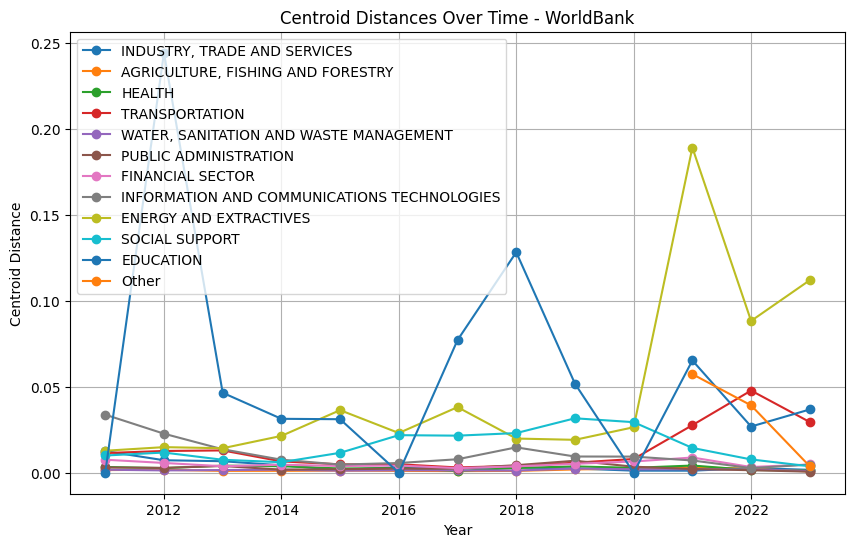

In [ ]:
# Function to plot centroid distances for multiple sectors and banks using matplotlib
def plot_centroid_distances(bank_name, bank_data):
    plt.figure(figsize=(10, 6))

    for sector, distance_data in bank_data.items():
        years = [year for year, _ in distance_data]
        distances = [distance for _, distance in distance_data]
        plt.plot(years, distances, marker='o', label=sector)

    plt.xlabel('Year')
    plt.ylabel('Centroid Distance')
    plt.title(f'Centroid Distances Over Time - {bank_name}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example of plotting for WorldBank
plot_centroid_distances('WorldBank', bank_distances['WorldBank'])


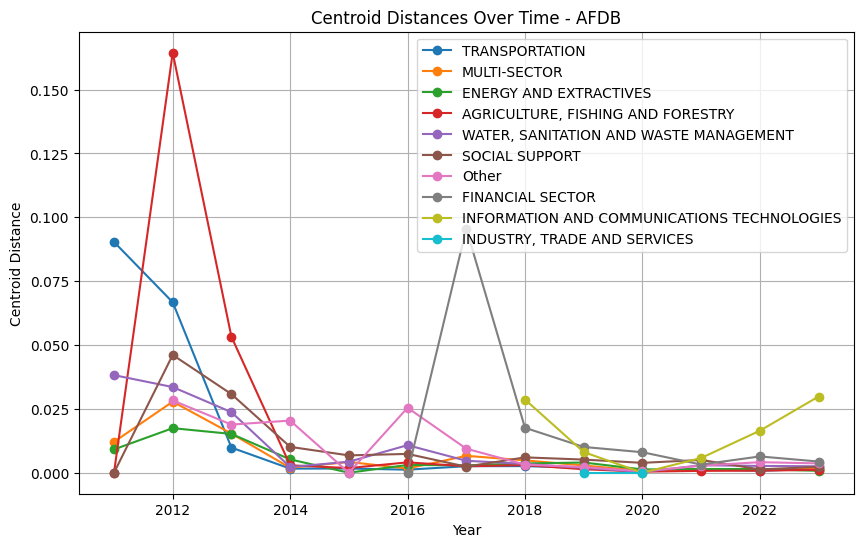

In [ ]:
plot_centroid_distances('AFDB', bank_distances['AFDB'])

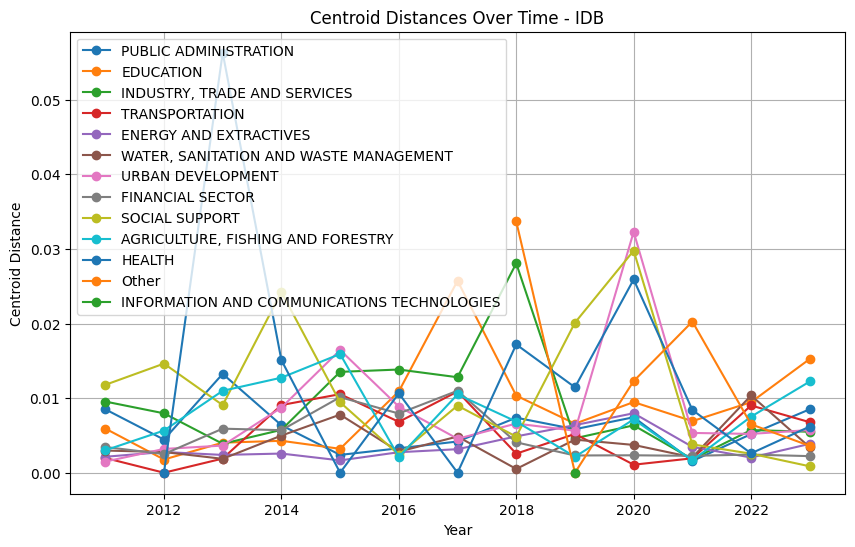

In [ ]:
plot_centroid_distances('IDB', bank_distances['IDB'])

In [ ]:
# Function to prepare data for interactive Plotly plots
def prepare_plot_data_for_plotly(bank_distances):
    plot_data = []

    for bank, bank_data in bank_distances.items():
        for sector, distance_data in bank_data.items():
            years = [year for year, _ in distance_data]
            distances = [distance for _, distance in distance_data]
            plot_data.append({
                'bank': bank,
                'sector': sector,
                'years': years,
                'distances': distances
            })

    return plot_data

# Function to create an interactive Plotly plot
def create_interactive_plot(plot_data):
    fig = go.Figure()

    for data in plot_data:
        fig.add_trace(go.Scatter(
            x=data['years'],
            y=data['distances'],
            mode='lines+markers',
            name=f"{data['bank']} - {data['sector']}",
            visible=True
        ))

    bank_options = sorted(set([data['bank'] for data in plot_data]))
    sector_options = sorted(set([data['sector'] for data in plot_data]))

    bank_dropdown = [
        {'label': bank, 'value': bank} for bank in bank_options
    ]
    sector_dropdown = [
        {'label': sector, 'value': sector} for sector in sector_options
    ]

    fig.update_layout(
        title="Centroid Distances Over Time by Bank and Sector",
        xaxis_title="Year",
        yaxis_title="Centroid Distance",
        updatemenus=[
            {
                'buttons': [
                    {'args': ['visible', [bank]], 'label': bank, 'method': 'update'}
                    for bank in bank_options
                ],
                'direction': 'down',
                'showactive': True,
                'x': 1,
                'xanchor': 'right',
                'y': 1.15,
                'yanchor': 'top'
            }
        ],
    )

    fig.show()

# Prepare the data and create the interactive plot
plot_data = prepare_plot_data_for_plotly(bank_distances)
create_interactive_plot(plot_data)


 By calculating the centroid distances across years, we can track how the focus (or nature) of a sector is changing over time. For example, if the distance between two centroids (from two consecutive years) is small, it means the sector’s data in those years is very similar.

**Visualize the centroid distances between the World Bank, AFDB, and IDB for common sectors**

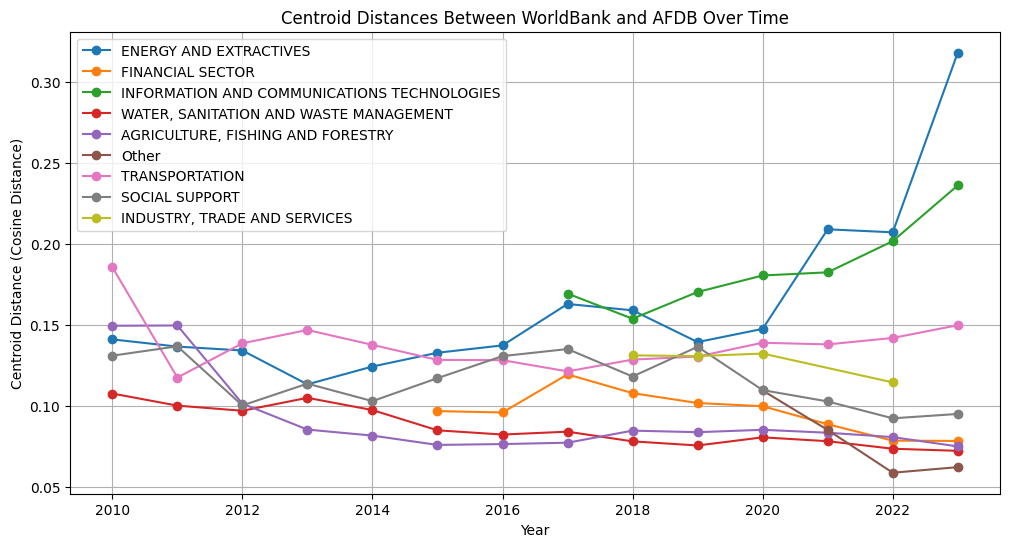

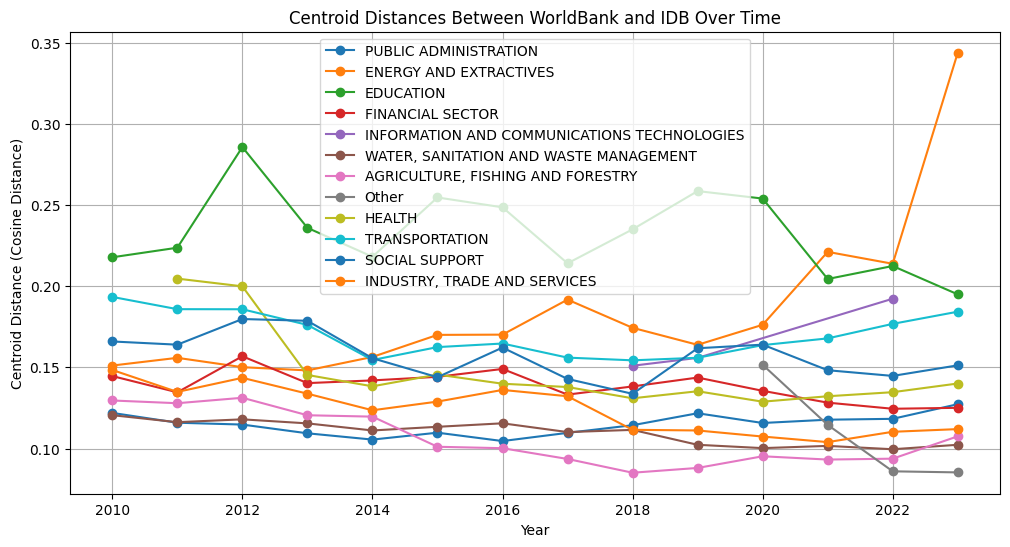

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate cosine distance between centroids
def calculate_cosine_distance(centroid1, centroid2):
    similarity = np.dot(centroid1, centroid2) / (np.linalg.norm(centroid1) * np.linalg.norm(centroid2))
    return 1 - similarity  # Cosine distance = 1 - cosine similarity

# Function to extract the common sectors between two banks
def get_common_sectors(centroids, bank1, bank2):
    common_sectors = set()
    for year in centroids[bank1]:
        for sector in centroids[bank1][year]:
            if sector in centroids[bank2].get(year, {}):
                common_sectors.add(sector)
    return common_sectors

# Function to prepare data for plotting
def prepare_centroid_distance_data(centroids, bank1, bank2):
    common_sectors = get_common_sectors(centroids, bank1, bank2)
    distance_data = {sector: [] for sector in common_sectors}

    for sector in common_sectors:
        for year in centroids[bank1]:
            if sector in centroids[bank1].get(year, {}) and sector in centroids[bank2].get(year, {}):
                centroid1 = centroids[bank1][year][sector]
                centroid2 = centroids[bank2][year][sector]
                distance = calculate_cosine_distance(centroid1, centroid2)
                distance_data[sector].append((year, distance))

    return distance_data

# Function to plot centroid distances between two banks for common sectors
def plot_centroid_distances_between_banks(centroid_distances, bank1, bank2):
    plt.figure(figsize=(12, 6))

    # Plot each sector's centroid distance over years
    for sector, distance_data in centroid_distances.items():
        years = [year for year, _ in distance_data]
        distances = [distance for _, distance in distance_data]
        plt.plot(years, distances, marker='o', label=sector)

    plt.xlabel('Year')
    plt.ylabel('Centroid Distance (Cosine Distance)')
    plt.title(f'Centroid Distances Between {bank1} and {bank2} Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example: Generate centroid distance data between World Bank and AFDB
centroid_distances_afdb = prepare_centroid_distance_data(centroids, 'WorldBank', 'AFDB')

# Plot the data for World Bank vs AFDB
plot_centroid_distances_between_banks(centroid_distances_afdb, 'WorldBank', 'AFDB')

# Example: Generate centroid distance data between World Bank and IDB
centroid_distances_idb = prepare_centroid_distance_data(centroids, 'WorldBank', 'IDB')

# Plot the data for World Bank vs IDB
plot_centroid_distances_between_banks(centroid_distances_idb, 'WorldBank', 'IDB')
